In [1]:
import os
import json
from collections import defaultdict

In [2]:
folder_path = "public/"

In [3]:
def analyze_json_files(folder_path):
    # Initialize counters
    total_files = 0
    filled_writer_count = 0
    filled_comment_count = 0

    # Iterate through all files in the folder
    for filename in os.listdir(folder_path):
        # Check if the file ends with '_tagged.json'
        if filename.endswith("_tagged.json"):
            total_files += 1
            file_path = os.path.join(folder_path, filename)
            
            # Read the JSON file
            with open(file_path, 'r', encoding='utf-8') as file:
                try:
                    data = json.load(file)
                    
                    # Check if 'writer' field is filled
                    if data.get("writer", "").strip():
                        filled_writer_count += 1
                    
                    # Check if 'comment' field is filled
                    if data.get("comment", "").strip():
                        filled_comment_count += 1
                
                except json.JSONDecodeError:
                    print(f"Error reading {filename}, skipping...")

    # Calculate percentages
    writer_percentage = (filled_writer_count / total_files) * 100 if total_files > 0 else 0
    comment_percentage = (filled_comment_count / total_files) * 100 if total_files > 0 else 0

    # Print the results
    print(f"Total JSON files ending with '_tagged.json': {total_files}")
    print(f"Files with filled 'writer' field: {filled_writer_count} ({writer_percentage:.2f}%)")
    print(f"Files with filled 'comment' field: {filled_comment_count} ({comment_percentage:.2f}%)")

In [4]:
analyze_json_files(folder_path)

Total JSON files ending with '_tagged.json': 1216
Files with filled 'writer' field: 309 (25.41%)
Files with filled 'comment' field: 329 (27.06%)


In [5]:
def list_all_labels(folder_path):
    # Initialize a set to collect unique labels/tags
    all_labels = set()

    # Define the tags/labels to ignore
    ignored_keywords = ["line"]

    # Iterate through all files in the folder
    for filename in os.listdir(folder_path):
        # Check if the file ends with '_tagged.json'
        if filename.endswith("_tagged.json"):
            file_path = os.path.join(folder_path, filename)
            
            # Read the JSON file
            with open(file_path, 'r', encoding='utf-8') as file:
                try:
                    data = json.load(file)
                    
                    # Add all keys (labels/tags) to the set, ignoring those containing "line"
                    for key in data.keys():
                        if not any(keyword in key.lower() for keyword in ignored_keywords):
                            all_labels.add(key)
                
                except json.JSONDecodeError:
                    print(f"Error reading {filename}, skipping...")

    # Convert the set to a sorted list for better readability
    all_labels = sorted(all_labels)

    # Print all unique labels/tags
    print("Unique labels/tags found in JSON files (excluding ignored tags):")
    for label in all_labels:
        print(label)


In [6]:
list_all_labels(folder_path)

Unique labels/tags found in JSON files (excluding ignored tags):
comment
imageFileName
modified
status
taggingBy
time
transcriber
transcription_QA
writer


In [7]:
def analyze_labels(folder_path):
    # Initialize a dictionary to count filled occurrences for each label/tag
    filled_count = defaultdict(int)
    total_count = defaultdict(int)

    # Define the tags/labels to ignore
    ignored_keywords = ["line"]

    # Iterate through all files in the folder
    for filename in os.listdir(folder_path):
        # Check if the file ends with '_tagged.json'
        if filename.endswith("_tagged.json"):
            file_path = os.path.join(folder_path, filename)
            
            # Read the JSON file
            with open(file_path, 'r', encoding='utf-8') as file:
                try:
                    data = json.load(file)
                    
                    # Iterate through each label/tag in the JSON file
                    for key, value in data.items():
                        # Ignore keys containing any of the ignored keywords
                        if not any(keyword in key.lower() for keyword in ignored_keywords):
                            total_count[key] += 1  # Increment total count for this label/tag
                            
                            # Check if the value is non-empty
                            if isinstance(value, str) and value.strip():
                                filled_count[key] += 1
                            elif isinstance(value, (int, float)) and value != 0:
                                filled_count[key] += 1
                            elif isinstance(value, list) and len(value) > 0:
                                filled_count[key] += 1
                
                except json.JSONDecodeError:
                    print(f"Error reading {filename}, skipping...")

    # Display the results
    print("Analysis of labels/tags (excluding ignored tags):")
    for label in sorted(total_count.keys()):
        filled = filled_count[label]
        total = total_count[label]
        percentage = (filled / total) * 100 if total > 0 else 0
        print(f"Label/Tag: '{label}' - Filled: {filled}, Total: {total}, Percentage Filled: {percentage:.2f}%")

In [8]:
analyze_labels(folder_path)

Analysis of labels/tags (excluding ignored tags):
Label/Tag: 'comment' - Filled: 329, Total: 1216, Percentage Filled: 27.06%
Label/Tag: 'imageFileName' - Filled: 1216, Total: 1216, Percentage Filled: 100.00%
Label/Tag: 'modified' - Filled: 1216, Total: 1216, Percentage Filled: 100.00%
Label/Tag: 'status' - Filled: 1216, Total: 1216, Percentage Filled: 100.00%
Label/Tag: 'taggingBy' - Filled: 1216, Total: 1216, Percentage Filled: 100.00%
Label/Tag: 'time' - Filled: 1214, Total: 1216, Percentage Filled: 99.84%
Label/Tag: 'transcriber' - Filled: 1216, Total: 1216, Percentage Filled: 100.00%
Label/Tag: 'transcription_QA' - Filled: 1216, Total: 1216, Percentage Filled: 100.00%
Label/Tag: 'writer' - Filled: 309, Total: 1216, Percentage Filled: 25.41%


In [9]:
def list_writer_names_with_count(folder_path):
    # Initialize a dictionary to count occurrences of each writer
    writer_count = defaultdict(int)

    # Iterate through all files in the folder
    for filename in os.listdir(folder_path):
        # Check if the file ends with '_tagged.json'
        if filename.endswith("_tagged.json"):
            file_path = os.path.join(folder_path, filename)
            
            # Read the JSON file
            with open(file_path, 'r', encoding='utf-8') as file:
                try:
                    data = json.load(file)
                    
                    # Check if 'writer' tag exists and is non-empty
                    writer = data.get("writer", "").strip()
                    if writer:
                        writer_count[writer] += 1
                
                except json.JSONDecodeError:
                    print(f"Error reading {filename}, skipping...")

    # Print all unique writer names with their counts
    print("Unique writer names and their counts found in JSON files:")
    for writer, count in sorted(writer_count.items()):
        print(f"- {writer}: {count}")

    # Print the total number of unique writers
    total_writers = len(writer_count)
    print(f"\nTotal number of unique writers: {total_writers}")

In [11]:
list_writer_names_with_count(folder_path)

Unique writer names and their counts found in JSON files:
- 'Abdallah Sfeir: 1
- <Constantine Elias>: 3
- <Jarhas Hanna Al-Shabtini>: 1
- <Jean Philipp Kmeid>: 4
- <Margaret El Haddad>: 2
- <Tawfiq>: 1
- <Youssef Darian>: 8
- <Youssef Ibrahim Yazbek>: 3
- Abdallah Daher: 1
- Abdo Fares: 1
- Adib Shiha: 1
- Antoine Richa: 1
- Antonios Elias: 1
- Aziz Khoury: 3
- Bishop Aghnathios Mbarak: 9
- Bishop Antoun Jbeir: 1
- Bishop Boulos Akl: 3
- Bishop Mkhayel Akhrass: 4
- Bishop Youseef El Khazen: 1
- Botros El Kfouny: 1
- Botros Feghaly: 3
- Daud Barkaat: 1
- Dr. Abdo Harb: 1
- Elias Abdallah: 1
- Elias Karbaj: 2
- Estephan Adib Salloum: 2
- Fathallah Khoury: 4
- Father Botros Dib: 1
- Father Botros Hasan: 4
- Father Botros Hassan: 1
- Father Boulos El-Mender: 10
- Father Elias Najm: 2
- Father Jerjes El Alam: 1
- Father Mkhayel Zreiby: 3
- Father Yaacoub Awad: 1
- Father Youhanna El Khoury: 2
- Father Youssef Baissary: 2
- Father Youssef Hajj: 3
- Father Youssef Hanna: 2
- Father Youssef Ha

In [ ]:
import os
import shutil
import re

def group_images_by_page(folder_path):
    # Regex pattern to capture the shared part of the filename without the counter
    pattern = re.compile(r"(.+_\d+)-\d+\.png$")

    # Create a dictionary to group images by their common filename
    image_groups = {}

    # Iterate through all files in the folder
    for filename in os.listdir(folder_path):
        if filename.endswith(".png"):
            # Match the shared part of the filename
            match = pattern.match(filename)
            if match:
                common_part = match.group(1)

                # Add the filename to the group based on the common part
                if common_part not in image_groups:
                    image_groups[common_part] = []
                image_groups[common_part].append(filename)

    # Create folders and move files
    for common_part, files in image_groups.items():
        # Create a folder with the common part as the name
        folder_name = os.path.join(folder_path, common_part)
        os.makedirs(folder_name, exist_ok=True)

        # Move each file to the corresponding folder
        for file in files:
            source = os.path.join(folder_path, file)
            destination = os.path.join(folder_name, file)
            shutil.move(source, destination)

    print(f"Images grouped successfully in {len(image_groups)} folders.")

In [ ]:
folder_path = "public 2"
group_images_by_page(folder_path)

Images grouped successfully in 619 folders.


In [ ]:
import os
import shutil

def move_folders_to_new_directory(source_path, destination_path):
    # Create the destination folder if it doesn't exist
    os.makedirs(destination_path, exist_ok=True)

    # Iterate through all items in the source folder
    for item in os.listdir(source_path):
        item_path = os.path.join(source_path, item)

        # Check if the item is a directory (folder)
        if os.path.isdir(item_path):
            # Move the folder to the destination
            destination_folder = os.path.join(destination_path, item)
            shutil.move(item_path, destination_folder)

    print(f"All folders moved successfully to {destination_path}")

In [ ]:
# Provide the path to the source folder containing the folders
source_path = "public 2"
# Provide the path to the new destination folder
destination_path = "/Users/hamza/Research/Muharaf/Lines"

move_folders_to_new_directory(source_path, destination_path)

All folders moved successfully to /Users/hamza/Research/Muharaf/Lines


In [ ]:
import os
import shutil
import re

def group_images_and_move(source_path, destination_path):
    # Regex pattern to capture the shared part of the filename before the hyphen
    pattern = re.compile(r"(.+?)-\d+\.png$")

    # Create the destination folder if it doesn't exist
    os.makedirs(destination_path, exist_ok=True)

    # Create a dictionary to group images by their common filename
    image_groups = {}

    # Iterate through all files in the source folder
    for filename in os.listdir(source_path):
        if filename.endswith(".png"):
            # Match the shared part of the filename
            match = pattern.match(filename)
            if match:
                common_part = match.group(1)

                # Add the filename to the group based on the common part
                if common_part not in image_groups:
                    image_groups[common_part] = []
                image_groups[common_part].append(filename)

    # Create folders in the destination and move the files
    for common_part, files in image_groups.items():
        # Create a folder with the common part in the destination directory
        folder_name = os.path.join(destination_path, common_part)
        os.makedirs(folder_name, exist_ok=True)

        # Move each file directly from source to the destination folder
        for file in files:
            source = os.path.join(source_path, file)
            destination = os.path.join(folder_name, file)
            shutil.move(source, destination)

    print(f"Images grouped and moved successfully to {destination_path}")

In [ ]:
# Provide the path to the source folder containing the folders
source_path = "Lines_txt"
# Provide the path to the new destination folder
destination_path = "/Users/hamza/Research/Muharaf/Lines"

In [ ]:
group_images_and_move(source_path, destination_path)


Images grouped and moved successfully to /Users/hamza/Research/Muharaf/Lines


In [ ]:
import os
import json
from collections import defaultdict

def list_writer_names_with_image_count(source_path, destination_path):
    # Initialize a dictionary to count occurrences of each writer
    writer_count = defaultdict(int)

    # Iterate through all files in the source folder
    for filename in os.listdir(source_path):
        # Check if the file ends with '_tagged.json'
        if filename.endswith("_tagged.json"):
            file_path = os.path.join(source_path, filename)
            
            # Read the JSON file
            with open(file_path, 'r', encoding='utf-8') as file:
                try:
                    data = json.load(file)
                    
                    # Check if 'writer' tag exists and is non-empty
                    writer = data.get("writer", "").strip()
                    if writer:
                        # Extract the folder name by removing the '_tagged.json' part from the filename
                        folder_name = filename.replace('_tagged.json', '')
                        
                        # Check if this folder exists in the destination path
                        destination_folder_path = os.path.join(destination_path, folder_name)
                        if os.path.exists(destination_folder_path) and os.path.isdir(destination_folder_path):
                            # Count the number of images (lines) in the destination folder
                            num_images = len([f for f in os.listdir(destination_folder_path) if f.endswith(".png")])
                            writer_count[writer] += num_images
                
                except json.JSONDecodeError:
                    print(f"Error reading {filename}, skipping...")

    # Print all unique writer names with their counts
    print("Unique writer names and their image counts (lines) found in folders:")
    for writer, count in sorted(writer_count.items()):
        print(f"- {writer}: {count}")

    # Print the total number of unique writers
    total_writers = len(writer_count)
    print(f"\nTotal number of unique writers: {total_writers}")

In [ ]:
# Provide the source and destination folder paths
source_path = "public"
destination_path = "Lines"

list_writer_names_with_image_count(source_path, destination_path)

Unique writer names and their image counts (lines) found in folders:
- 'Abdallah Sfeir: 22
- <Constantine Elias>: 48
- <Jarhas Hanna Al-Shabtini>: 18
- <Jean Philipp Kmeid>: 94
- <Margaret El Haddad>: 42
- <Tawfiq>: 19
- <Youssef Darian>: 162
- <Youssef Ibrahim Yazbek>: 73
- Abdallah Daher: 13
- Abdo Fares: 18
- Adib Shiha: 24
- Antoine Richa: 31
- Antonios Elias: 19
- Aziz Khoury: 49
- Bishop Aghnathios Mbarak: 183
- Bishop Antoun Jbeir: 25
- Bishop Boulos Akl: 47
- Bishop Mkhayel Akhrass: 94
- Bishop Youseef El Khazen: 26
- Botros El Kfouny: 25
- Botros Feghaly: 73
- Daud Barkaat: 21
- Dr. Abdo Harb: 22
- Elias Abdallah: 21
- Elias Karbaj: 34
- Estephan Adib Salloum: 55
- Fathallah Khoury: 75
- Father Botros Dib: 32
- Father Botros Hasan: 85
- Father Botros Hassan: 24
- Father Boulos El-Mender: 203
- Father Elias Najm: 54
- Father Jerjes El Alam: 20
- Father Mkhayel Zreiby: 76
- Father Yaacoub Awad: 20
- Father Youhanna El Khoury: 33
- Father Youssef Baissary: 37
- Father Youssef Haj

In [ ]:
import os
import json
from collections import defaultdict
import matplotlib.pyplot as plt

def list_writer_names_with_image_count(source_path, destination_path):
    # Initialize a dictionary to count occurrences of each writer
    writer_count = defaultdict(int)

    # Iterate through all files in the source folder
    for filename in os.listdir(source_path):
        # Check if the file ends with '_tagged.json'
        if filename.endswith("_tagged.json"):
            file_path = os.path.join(source_path, filename)
            
            # Read the JSON file
            with open(file_path, 'r', encoding='utf-8') as file:
                try:
                    data = json.load(file)
                    
                    # Check if 'writer' tag exists and is non-empty
                    writer = data.get("writer", "").strip()
                    if writer:
                        # Extract the folder name by removing the '_tagged.json' part from the filename
                        folder_name = filename.replace('_tagged.json', '')
                        
                        # Check if this folder exists in the destination path
                        destination_folder_path = os.path.join(destination_path, folder_name)
                        if os.path.exists(destination_folder_path) and os.path.isdir(destination_folder_path):
                            # Count the number of images (lines) in the destination folder
                            num_images = len([f for f in os.listdir(destination_folder_path) if f.endswith(".png")])
                            writer_count[writer] += num_images
                
                except json.JSONDecodeError:
                    print(f"Error reading {filename}, skipping...")

    # Plotting the results as a histogram
    writers = list(writer_count.keys())
    image_counts = list(writer_count.values())

    plt.figure(figsize=(10, 15))
    plt.barh(writers, image_counts, color='skyblue')  # Horizontal bar chart
    plt.ylabel('Writers')
    plt.xlabel('Number of Images (Lines)')
    plt.title('Number of Images (Lines) per Writer')
    plt.tight_layout()
    plt.show()


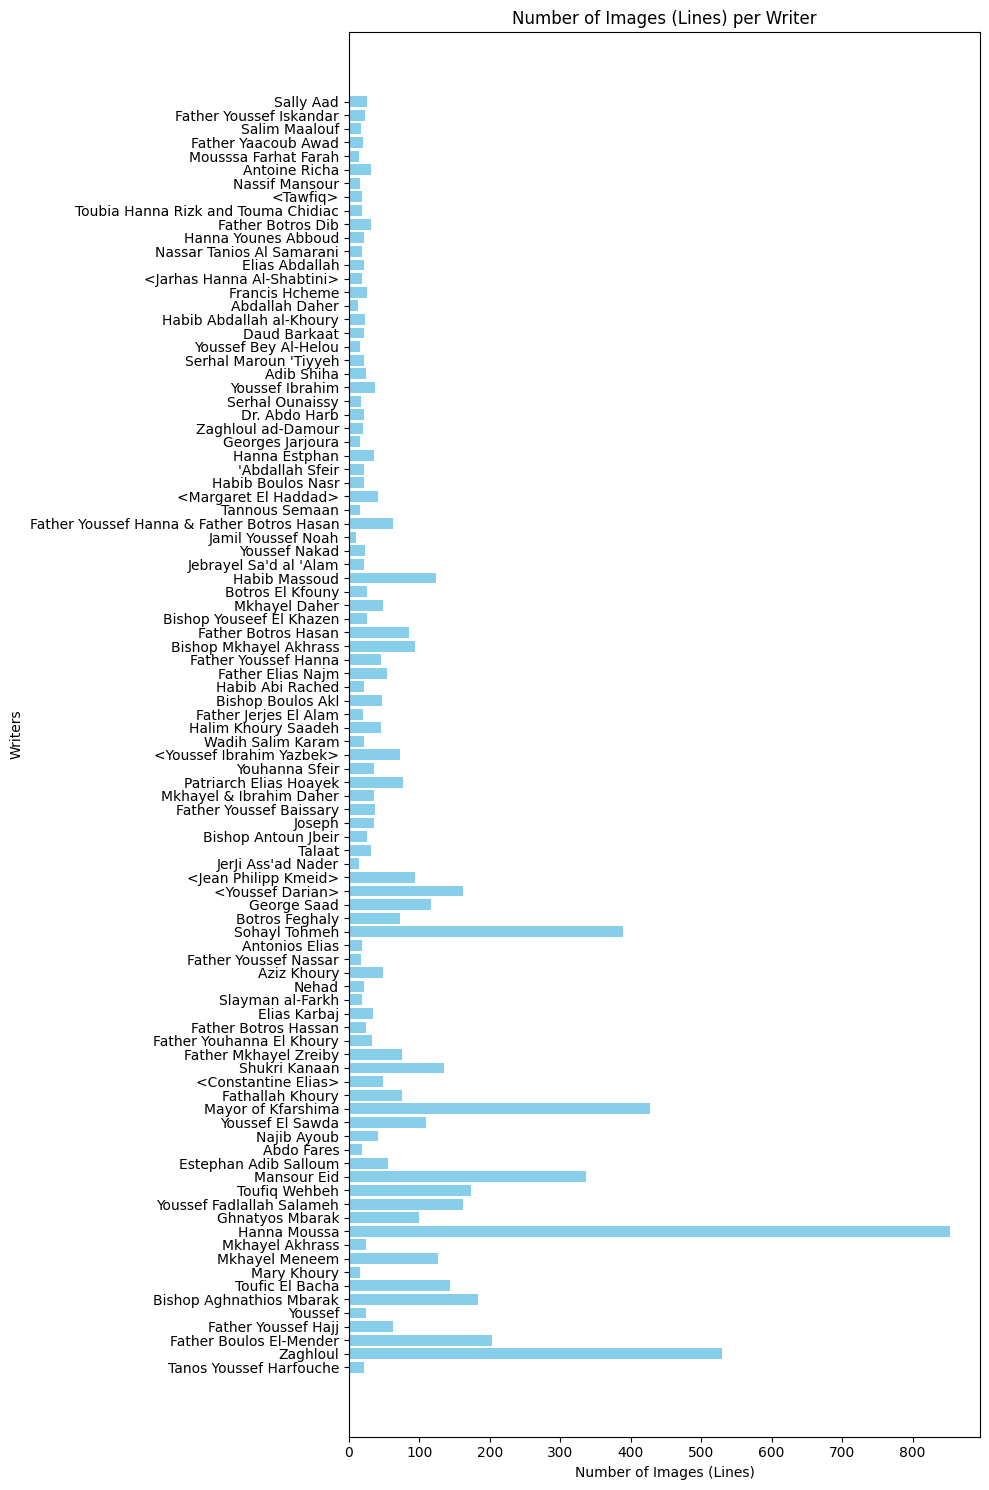

In [ ]:
# Provide the source and destination folder paths
source_path = "public"
destination_path = "Lines"

list_writer_names_with_image_count(source_path, destination_path)

In [ ]:
import os
import json
import pandas as pd

# List of prefixes from the provided table
prefixes = [
    '00000', '158', '159', '160', '2015', '0105-12P', '1940Jbeil', '26025', '26066', '27404', 'AF', 'AJN', 'AP', 'AR', 
    'AnF', 'BEK', 'Baddour', 'Church', 'EAC', 'EAK', 'ES', 'FC', 'HM', 'JEH', 'JPK', 'JoM', 'KEllis', 'KJoseph', 'ME', 
    'MG', 'MH', 'MISC_R', 'MK', 'MUKF', 'MeM', 'Misc', 'Nasrallah', 'OLM', 'Oussani', 'QAJE', 'QBat', 'SB', 'ST', 
    'TAttallah', 'TB', 'YAL', 'YFS', 'YS', 'kc0061', 'kc0066'
]

# Function to extract prefix from filename
def get_prefix(filename):
    for prefix in prefixes:
        if filename.startswith(prefix):
            return prefix
    return ""  # Return empty string if no matching prefix is found

def create_manual_labeling_excel(source_folder, output_file):
    # List to store rows for the Excel file
    data = []

    # Iterate through all files in the folder
    for filename in os.listdir(source_folder):
        if filename.endswith("_tagged.json"):
            # Remove the "_tagged.json" part from the filename
            clean_filename = filename.replace('_tagged.json', '')
            file_path = os.path.join(source_folder, filename)
            with open(file_path, 'r', encoding='utf-8') as file:
                try:
                    data_json = json.load(file)
                    # If writer tag is empty, add the file to the list
                    if not data_json.get("writer", "").strip():
                        prefix = get_prefix(clean_filename)
                        data.append([clean_filename, prefix, "", ""])
                except json.JSONDecodeError:
                    print(f"Error reading {filename}, skipping...")

    # Create DataFrame for manual labeling
    df = pd.DataFrame(data, columns=['Image Filename', 'Prefix', 'Writer Name (Arabic)', 'Writer Name (English)'])
    
    # Save to Excel
    df.to_excel(output_file, index=False)
    print(f"Excel file created: {output_file}")

In [ ]:
# Example usage
source_folder = "/Users/hamza/Research/Muharaf/public"
output_file = "manual_labeling.xlsx"
create_manual_labeling_excel(source_folder, output_file)

Excel file created: manual_labeling.xlsx


In [ ]:
import os
import shutil
import json

def move_empty_writer_files(source_folder, new_folder):
    # Create the new folder if it doesn't exist
    os.makedirs(new_folder, exist_ok=True)

    # Iterate through all files in the source folder
    for filename in os.listdir(source_folder):
        if filename.endswith("_tagged.json"):
            file_path = os.path.join(source_folder, filename)
            
            # Check if the _tagged.json file exists
            if not os.path.exists(file_path):
                print(f"File not found: {file_path}, skipping...")
                continue
            
            with open(file_path, 'r', encoding='utf-8') as file:
                try:
                    data_json = json.load(file)
                    # If the writer tag is empty, move all related files
                    if not data_json.get("writer", "").strip():
                        # Extract the base name of the file (without _tagged.json)
                        base_name = filename.replace('_tagged.json', '')

                        # Move all files that start with the same base name
                        for file in os.listdir(source_folder):
                            if file.startswith(base_name):
                                source_file = os.path.join(source_folder, file)
                                destination_file = os.path.join(new_folder, file)
                                
                                # Ensure the file exists before moving
                                if os.path.exists(source_file):
                                    shutil.move(source_file, destination_file)
                                    print(f"Moved: {file}")
                                else:
                                    print(f"File not found: {source_file}, skipping...")
                except json.JSONDecodeError:
                    print(f"Error reading JSON from {filename}, skipping...")

In [ ]:
source_folder = "/Users/hamza/Research/Muharaf/public"  # Replace with actual path
new_folder = "/Users/hamza/Research/Muharaf/no_writer"  # Replace with actual path
move_empty_writer_files(source_folder, new_folder)

Moved: YAL4A_01_02r.jpg
Moved: YAL4A_01_02r.xml
Moved: YAL4A_01_02r.json
Moved: YAL4A_01_02r_annotate_carlos.json
Moved: YAL4A_01_02r_tagged.json
Moved: kc0066_01_01_1873diary_020.xml
Moved: kc0066_01_01_1873diary_020.jpg
Moved: kc0066_01_01_1873diary_020.json
Moved: kc0066_01_01_1873diary_020_tagged.json
Moved: kc0066_01_01_1873diary_020_annotate_carlos.json
Moved: kc0061_01_04_19210316_001.json
Moved: kc0061_01_04_19210316_001_tagged.json
Moved: kc0061_01_04_19210316_001.jpg
Moved: kc0061_01_04_19210316_001.xml
Moved: kc0061_01_04_19210316_001_annotate_elias.json
Moved: KJoseph18990913-001_1_annotate_georges.json
Moved: KJoseph18990913-001_1.jpg
Moved: KJoseph18990913-001_1.xml
Moved: KJoseph18990913-001_1_tagged.json
Moved: KJoseph18990913-001_1.json
Moved: Baddour_Letter-1_annotate_elias.json
Moved: Baddour_Letter-1_tagged.json
Moved: Baddour_Letter-1.xml
Moved: Baddour_Letter-1.jpg
Moved: Baddour_Letter-1.json
Moved: QBat19D_004r.json
Moved: QBat19D_004r.xml
Moved: QBat19D_004r.jp

In [ ]:
import os
import json
import pandas as pd

# List of prefixes from the provided table
prefixes = [
    '00000', '158', '159', '160', '2015', '0105-12P', '1940Jbeil', '26025', '26066', '27404', 'AF', 'AJN', 'AP', 'AR', 
    'AnF', 'BEK', 'Baddour', 'Church', 'EAC', 'EAK', 'ES', 'FC', 'HM', 'JEH', 'JPK', 'JoM', 'KEllis', 'KJoseph', 'ME', 
    'MG', 'MH', 'MISC_R', 'MK', 'MUKF', 'MeM', 'Misc', 'Nasrallah', 'OLM', 'Oussani', 'QAJE', 'QBat', 'SB', 'ST', 
    'TAttallah', 'TB', 'YAL', 'YFS', 'YS', 'kc0061', 'kc0066'
]

# Function to extract prefix from filename
def get_prefix(filename):
    for prefix in prefixes:
        if filename.startswith(prefix):
            return prefix
    return ""  # Return empty string if no matching prefix is found

def create_writer_filled_csv(source_folder, output_file):
    # List to store rows for the CSV file
    data = []

    # Iterate through all files in the folder
    for filename in os.listdir(source_folder):
        if filename.endswith("_tagged.json"):
            # Remove the "_tagged.json" part from the filename
            clean_filename = filename.replace('_tagged.json', '')
            file_path = os.path.join(source_folder, filename)
            with open(file_path, 'r', encoding='utf-8') as file:
                try:
                    data_json = json.load(file)
                    # If writer tag is filled, add the file to the list
                    writer_name = data_json.get("writer", "").strip()
                    if writer_name:
                        prefix = get_prefix(clean_filename)
                        data.append([clean_filename, prefix, writer_name])
                except json.JSONDecodeError:
                    print(f"Error reading {filename}, skipping...")

    # Create DataFrame for writer-filled rows
    df = pd.DataFrame(data, columns=['Image Filename', 'Prefix', 'Writer Name (English)'])
    
    # Save to CSV
    df.to_csv(output_file, index=False)
    print(f"CSV file created: {output_file}")

In [ ]:
# Example usage
source_folder = "/Users/hamza/Research/Muharaf/has_writer"
output_file = "/Users/hamza/Research/Muharaf/writer_filled.csv"
create_writer_filled_csv(source_folder, output_file)

CSV file created: /Users/hamza/Research/Muharaf/writer_filled.csv


In [ ]:
import pandas as pd
import re

def clean_filename(filename):
    # Clean the filename by removing extra spaces and special characters
    cleaned = re.sub(r'\s+', ' ', filename).strip()  # Replace multiple spaces with a single space
    return cleaned

def merge_writer_xlsx(original_csv, labeled_xlsx, output_csv):
    # Read the original CSV file
    original_df = pd.read_csv(original_csv)

    # Read the labeled Excel file
    labeled_df = pd.read_excel(labeled_xlsx)

    # Clean 'Image Filename' and 'Prefix' columns in both dataframes
    original_df['Image Filename'] = original_df['Image Filename'].apply(clean_filename)
    original_df['Prefix'] = original_df['Prefix'].str.strip()

    labeled_df['Image Filename'] = labeled_df['Image Filename'].apply(clean_filename)
    labeled_df['Prefix'] = labeled_df['Prefix'].str.strip()

    # Ensure only rows with non-empty 'Writer Name (English)' are selected
    labeled_filled_df = labeled_df[labeled_df['Writer Name (English)'].notna() & (labeled_df['Writer Name (English)'] != "")]

    # Debugging: Check the number of rows with new labels
    print(f"Number of rows with new 'Writer Name (English)': {len(labeled_filled_df)}")

    # Merge the original and labeled dataframes on 'Image Filename' and 'Prefix'
    # This is a left merge, keeping all rows from the original_df
    merged_df = pd.merge(
        original_df, 
        labeled_filled_df[['Image Filename', 'Prefix', 'Writer Name (English)']],
        on=['Image Filename', 'Prefix'], 
        how='left'
    )

    # Combine 'Writer Name (English)' from the labeled dataframe into the original dataframe
    merged_df['Writer Name (English)'] = merged_df['Writer Name (English)_y'].combine_first(merged_df['Writer Name (English)_x'])

    # Drop the redundant columns created by the merge
    merged_df = merged_df.drop(columns=['Writer Name (English)_x', 'Writer Name (English)_y'])

    # Debugging: Check how many rows now have writer names filled
    num_filled = merged_df['Writer Name (English)'].notna().sum()
    print(f"Number of rows with filled 'Writer Name (English)' in the merged dataframe: {num_filled}")
    
    # Save the merged result to a new CSV file
    merged_df.to_csv(output_csv, index=False)
    print(f"Merged CSV file created: {output_csv}")

In [ ]:
# Example usage
original_csv = "/Users/hamza/Research/Muharaf/writer_filled.csv"  # CSV generated earlier
labeled_xlsx = "/Users/hamza/Research/Muharaf/manual_labeling.xlsx"  # CSV with manual labels
output_csv = "/Users/hamza/Research/Muharaf/merged_writer.csv"  # Output merged CSV
merge_writer_xlsx(original_csv, labeled_xlsx, output_csv)

Number of rows with new 'Writer Name (English)': 688
Number of rows with filled 'Writer Name (English)' in the merged dataframe: 309
Merged CSV file created: /Users/hamza/Research/Muharaf/merged_writer.csv


In [ ]:
import pandas as pd

def merge_and_add_new_data(original_csv, labeled_xlsx, output_csv):
    # Read the original CSV file
    original_df = pd.read_csv(original_csv)

    # Read the labeled Excel file
    labeled_df = pd.read_excel(labeled_xlsx)

    # Filter labeled dataframe for non-empty 'Writer Name (English)' entries
    labeled_filled_df = labeled_df[labeled_df['Writer Name (English)'].notna() & (labeled_df['Writer Name (English)'] != "")]

    # Select only the 3 columns we care about: 'Image Filename', 'Prefix', 'Writer Name (English)'
    original_df = original_df[['Image Filename', 'Prefix', 'Writer Name (English)']]
    labeled_filled_df = labeled_filled_df[['Image Filename', 'Prefix', 'Writer Name (English)']]

    # Append the new labeled rows (from Excel) to the original dataset
    combined_df = pd.concat([original_df, labeled_filled_df], ignore_index=True)

    # Remove duplicate rows based on 'Image Filename' and 'Prefix', keeping the last occurrence (i.e., the newly labeled ones)
    combined_df.drop_duplicates(subset=['Image Filename', 'Prefix'], keep='last', inplace=True)

    # Save the final result to a new CSV file
    combined_df.to_csv(output_csv, index=False)
    print(f"Combined CSV file created: {output_csv}")

In [ ]:
# Example usage
original_csv = "/Users/hamza/Research/Muharaf/writer_filled.csv"  # CSV generated earlier
labeled_xlsx = "/Users/hamza/Research/Muharaf/manual_labeling.xlsx"  # CSV with manual labels
output_csv = "/Users/hamza/Research/Muharaf/merged_writer.csv"  # Output merged CSV

# Run the merge function
merge_and_add_new_data(original_csv, labeled_xlsx, output_csv)

Combined CSV file created: /Users/hamza/Research/Muharaf/merged_writer.csv


In [ ]:
import pandas as pd
from collections import defaultdict

def list_writer_names_with_image_count(csv_file_path):
    # Load the merged CSV file into a dataframe
    df = pd.read_csv(csv_file_path)

    # Initialize a dictionary to count occurrences of each writer
    writer_count = defaultdict(int)

    # Iterate through the dataframe and count occurrences of each writer
    for _, row in df.iterrows():
        writer = row['Writer Name (English)'].strip()  # Strip any extra spaces
        if writer:
            writer_count[writer] += 1

    # Print all unique writer names with their counts
    print("Unique writer names and their image counts (lines) found in the CSV:")
    for writer, count in sorted(writer_count.items()):
        print(f"- {writer}: {count}")

    # Print the total number of unique writers
    total_writers = len(writer_count)
    print(f"\nTotal number of unique writers: {total_writers}")

    # Optionally, return the dictionary if you need to use it elsewhere
    return writer_count

# Example usage
csv_file_path = '/Users/hamza/Research/Muharaf/merged_writer.csv'
list_writer_names_with_image_count(csv_file_path)

Unique writer names and their image counts (lines) found in the CSV:
- Abd al-Hajj: 2
- Abd al-Khaliq Farid: 2
- Abdallah Daher: 1
- Abdallah Sfeir: 1
- Abdo Fares: 1
- Abdulaziz bin Abdul Rahman Al Faisal Al Saud: 20
- Adham Al Jundi: 1
- Adib Shiha: 1
- Ahmed Shakir alKarmi: 1
- Ameen Rihani: 43
- Amin Farhat: 3
- Angele Ellis: 4
- Antoine Richa: 1
- Antonios Elias: 1
- Asaad Koury Tobia Attallah: 3
- Assad Al-Khoury: 1
- Assad Darouich Zacharias: 5
- Aziz Khoury: 3
- Bechara El Khoury: 6
- Bishara Mar'i Mansour: 2
- Bishop Aghnathios Mbarak: 9
- Bishop Antoun Jbeir: 1
- Bishop Boulos Akl: 3
- Bishop Mkhayel Akhrass: 5
- Bishop Youseef El Khazen: 1
- Bishop Youssef Darian: 9
- Botros El Kfouny: 1
- Botros Feghaly: 3
- Brother Ibrahim: 1
- Brother of Joseph Oussani: 1
- Catherine Yazbek Al-Badawi: 4
- Constantine Elias: 5
- Dani Al-Sibaqa: 1
- Daoud Mujaes: 4
- Daud Barkaat: 1
- Dr. Abdo Harb: 1
- Eissa alKhouri: 6
- Elia Abu Madi: 2
- Elias Abdallah: 1
- Elias Abu Shabaki: 8
- Elias 

defaultdict(int,
            {'Malvina Choieree': 1,
             'Your nephew Maroun': 4,
             'Sister Victor N. Khoury': 3,
             'Maroun Al-Khoury Maroun (Joseph Benjamin El-Khouri )': 2,
             'Father Youssef Nassar': 1,
             'Shibli Barakat witnesses': 1,
             'Mousssa Farhat Farah': 1,
             'Nassar Tanios Al Samarani': 1,
             'Keserwan Finance Officer': 1,
             'Serhal Ounaissy': 1,
             'Elias Abdallah': 1,
             'Your son George': 11,
             'Amin Farhat': 3,
             'Patriarch Elias Hoayek': 4,
             'Bishop Boulos Akl': 3,
             'Ameen Rihani': 43,
             'Shibli N. Damus': 13,
             'Naoum Mokarzel': 3,
             'Eissa alKhouri': 6,
             'Girgi Dimitri Sursock': 8,
             'Felix Faris': 27,
             'Muhammad Hussain Najafi': 2,
             'May Ziadeh': 12,
             'Victor Shemil': 1,
             'Ahmed Shakir alKarmi': 1,
        